# Tick library - guide and testing

## Python Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib
# import matplotlib.pyplot as plt

In [2]:
# from scipy import optimize
from scipy.optimize import minimize
from scipy.optimize import Bounds

In [3]:
from functools import partial

In [4]:
from numba import jit

## Tick Imports

In [6]:
%matplotlib inline

In [7]:
from tick.hawkes import SimuHawkes, SimuHawkesMulti
from tick.base import TimeFunction
from tick.hawkes import HawkesKernelTimeFunc, HawkesKernel0
from tick.hawkes import HawkesKernelSumExp, HawkesKernelExp
from tick.hawkes import HawkesEM, HawkesSumExpKern
# from tick.hawkes import SimuPoissonProcess, SimuInhomogeneousPoisson
# from tick.hawkes import HawkesBasisKernels, HawkesSumGaussians
from tick.plot import plot_timefunction
# from tick.plot import plot_point_process
from tick.plot import plot_hawkes_kernels
# from tick.plot import plot_basis_kernels

## Simple example of exponential Kernel

In [8]:
α1 = 0.6
β1 = 0.8
λ01 = 1.2

In [9]:
def ek1(t):
    return α1 * np.exp(-β1 * t)

In [10]:
sup1 = 10

In [11]:
def time_funct(f, support, steps=100, inter_mode=TimeFunction.InterConstRight):
    t_values = np.linspace(0, support, steps + 1)
    y_values = f(t_values)
    return TimeFunction(values=(t_values, y_values),
                        border_type=TimeFunction.Border0,
                        # inter_mode=TimeFunction.InterLinear,
                        inter_mode=inter_mode)

In [12]:
ekc1 = time_funct(ek1, sup1)

In [13]:
ektf1 = HawkesKernelTimeFunc(ekc1)

In [14]:
ekprm1 = HawkesKernelExp(α1 / β1, β1)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


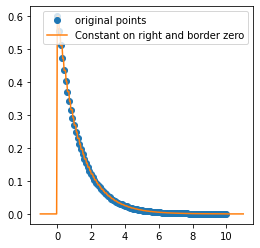

In [15]:
plot_timefunction(ekc1)

In [16]:
n_paths = 100

In [17]:
end_time_1 = 100
end_time_2 = 1000
end_time_3 = 10000

In [18]:
hawkestf1 = SimuHawkes(baseline=[λ01], kernels=[[ektf1]], end_time=end_time_1, verbose=False, seed=13)
hawkestf2 = SimuHawkes(baseline=[λ01], kernels=[[ektf1]], end_time=end_time_2, verbose=False, seed=13)
hawkestf3 = SimuHawkes(baseline=[λ01], kernels=[[ektf1]], end_time=end_time_3, verbose=False, seed=13)

In [19]:
multitf1 = SimuHawkesMulti(hawkestf1, n_simulations=n_paths)
multitf2 = SimuHawkesMulti(hawkestf2, n_simulations=n_paths)
multitf3 = SimuHawkesMulti(hawkestf3, n_simulations=n_paths)

In [20]:
multitf1.simulate()
multitf2.simulate()
multitf3.simulate()

In [21]:
hawkesprm1 = SimuHawkes(baseline=[λ01], kernels=[[ekprm1]], end_time=end_time_1, verbose=False, seed=13)
hawkesprm2 = SimuHawkes(baseline=[λ01], kernels=[[ekprm1]], end_time=end_time_2, verbose=False, seed=13)
hawkesprm3 = SimuHawkes(baseline=[λ01], kernels=[[ekprm1]], end_time=end_time_3, verbose=False, seed=13)

In [22]:
multiprm1 = SimuHawkesMulti(hawkesprm1, n_simulations=n_paths)
multiprm2 = SimuHawkesMulti(hawkesprm2, n_simulations=n_paths)
multiprm3 = SimuHawkesMulti(hawkesprm3, n_simulations=n_paths)

In [23]:
multiprm1.simulate()
multiprm2.simulate()
multiprm3.simulate()

In [24]:
def dtsn0(ts):
    return ts[-1] - ts[:-1]

In [25]:
def ll(θ, ts, ddts, dtsns):
    λ0 = θ[0]
    α = θ[1]
    β = θ[2]
    tn = ts[-1]
    ebdts = np.exp(-β * ddts)
    ri = np.zeros(len(ts))
    for i in range(1, len(ts)):
        ri[i] = ebdts[i - 1] * (1 + ri[i - 1])
    s1 = np.sum(1 - np.exp(-β * dtsns))
    s2 = np.sum(np.log(λ0 + α * ri))
    return -(tn * (1 - λ0) - (α / β) * s1 + s2)

In [26]:
def_bounds = [(0.01, 2.0), (0.01, 100.), (0.01, 200.)]

In [27]:
def_constraint = {'type': 'ineq', 'fun': lambda x:  x[2] - x[1]}

In [28]:
def_x0 = np.array([1., 0.3, 0.5])

In [29]:
%%time

for path in multiprm3.timestamps:
    ts = path[0]
    ddts = np.diff(ts)
    dtsns = dtsn0(ts)
    a = ll(def_x0, ts=ts, ddts=ddts, dtsns=dtsns)

CPU times: user 2.65 s, sys: 4.83 ms, total: 2.66 s
Wall time: 2.66 s


In [29]:
def findθ(tss, bounds=def_bounds, x0=def_x0):
    results = []
    for path in tss:
        ts = path[0]
        ddts = np.diff(ts)
        dtsns = dtsn0(ts)
        optim0 = partial(ll, ts=ts, ddts=ddts, dtsns=dtsns)
        res0 = minimize(optim0, x0, method='SLSQP',
                        bounds=def_bounds, constraints=def_constraint)
        results = results + [res0.x]
    return np.array(results)

In [30]:
%%time

np.mean(findθ(multiprm1.timestamps), axis=0)

CPU times: user 2.04 s, sys: 5.05 ms, total: 2.04 s
Wall time: 2.04 s


array([1.40146686, 0.59475205, 0.87367101])

In [31]:
%%time

np.mean(findθ(multitf1.timestamps), axis=0)

CPU times: user 2.09 s, sys: 3.94 ms, total: 2.1 s
Wall time: 2.1 s


array([1.40909929, 0.63330238, 0.87605033])

In [34]:
%%time

np.mean(findθ(multiprm2.timestamps), axis=0)

CPU times: user 14.3 s, sys: 11.6 ms, total: 14.3 s
Wall time: 14.3 s


array([1.2216118 , 0.59841848, 0.80240067])

In [35]:
%%time

np.mean(findθ(multitf2.timestamps), axis=0)

CPU times: user 16.8 s, sys: 18.3 ms, total: 16.8 s
Wall time: 16.8 s


array([1.22882867, 0.62591835, 0.80715438])

In [36]:
%%time

np.mean(findθ(multiprm3.timestamps), axis=0)

CPU times: user 2min 24s, sys: 73.2 ms, total: 2min 24s
Wall time: 2min 24s


array([1.20246537, 0.60137323, 0.80254629])

In [37]:
%%time

np.mean(findθ(multitf3.timestamps), axis=0)

CPU times: user 3min 17s, sys: 259 ms, total: 3min 17s
Wall time: 3min 18s


array([1.20185777, 0.62456703, 0.80126463])

## Simple example of exponential Kernel with latency

### Latency = 0 (to compare with previous function)

In [32]:
lat1 = 0

In [33]:
def time_funclat(f, support, lat=0, steps=100,
              inter_mode=TimeFunction.InterConstRight):
    t_values = np.linspace(0, support, steps + 1)
    y_values = f(t_values)
    if lat > 0:
        t_values_lat = np.linspace(0, lat, steps)
        y_values_lat = np.zeros(steps)
        t_values_shifted = t_values + lat
        t_all = np.concatenate((t_values_lat, t_values_shifted))
        y_all = np.concatenate((y_values_lat, y_values))
    else:
        t_all = t_values.view()
        y_all = y_values.view()
    return TimeFunction(values=(t_all, y_all),
                        border_type=TimeFunction.Border0,
                        # inter_mode=TimeFunction.InterLinear,
                        inter_mode=inter_mode)

In [34]:
ekc2 = time_funclat(ek1, sup1, lat1)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


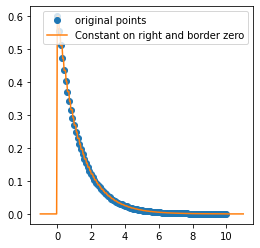

In [35]:
plot_timefunction(ekc2)

In [36]:
ektf2 = HawkesKernelTimeFunc(ekc2)

In [37]:
hawkestf2_1 = SimuHawkes(baseline=[λ01], kernels=[[ektf2]], end_time=end_time_1, verbose=False, seed=13)
hawkestf2_2 = SimuHawkes(baseline=[λ01], kernels=[[ektf2]], end_time=end_time_2, verbose=False, seed=13)
hawkestf2_3 = SimuHawkes(baseline=[λ01], kernels=[[ektf2]], end_time=end_time_3, verbose=False, seed=13)

In [38]:
multitf2_1 = SimuHawkesMulti(hawkestf2_1, n_simulations=n_paths)
multitf2_2 = SimuHawkesMulti(hawkestf2_2, n_simulations=n_paths)
multitf2_3 = SimuHawkesMulti(hawkestf2_3, n_simulations=n_paths)

In [39]:
multitf2_1.simulate()
multitf2_2.simulate()
multitf2_3.simulate()

In [44]:
del findtlat

In [45]:
@jit(nopython=True)
def findtlat(ts, lat, i):
    j = np.searchsorted(ts[i + 1:] - lat - ts[i], 0) + i + 1
    if j <= len(ts) - 1:
        return [j, ts[j] - lat - ts[i]]
    else:
        return [j, 0.]

In [98]:
del ddtsi

In [107]:
def ddtsi(ts, lat):
    dtsis = dict()
    for i in range(0, len(ts) - 1):
        k, v = findtlat(ts, lat, i)
        if v > 0:
            if int(k) not in dtsis:
                dtsis[int(k)] = [v]
            else:
                dtsis[k].extend([v])
    return [np.array(dtsis.get(i, np.inf)) for i in range(1, len(ts))]

In [117]:
del dtsi

In [49]:
# @jit(nopython=True)
# def dtsi(ts, lat):
#     selt = [np.extract(np.logical_and(ts[:i] < ts[i] - lat, ts[:i] >= ts[i - 1] - lat), ts[i] - lat - ts[:i])
#                 for i in range(1, len(ts))]
#     return [x if len(x) > 0 else np.array([np.inf]) for x in selt]

In [50]:
def heav(ts, lat):
    return np.heaviside(ts[-1] - lat - ts[:-1], 0)

In [51]:
def dtsn(ts, lat):
    return (ts[-1] - lat - ts[:-1]) * heav(ts, lat)

In [52]:
multitf2_1.timestamps[0][0][:11]

array([1.22146344, 1.91775808, 2.04672348, 2.77004741, 3.10786929,
       3.30121374, 5.22542323, 6.39892795, 6.44653378, 7.57377226,
       7.83046309])

In [119]:
# dtsi(multitf2_1.timestamps[0][0][:11], 1)

In [120]:
# ddtsi(multitf2_1.timestamps[0][0][:11], 1)

In [162]:
del lllat

In [163]:
def lllat(θ, ts, ddts, dtsis, dtsns, lat=0):
    λ0 = θ[0]
    α = θ[1]
    β = θ[2]
    tn = ts[-1]
    ebdts = np.exp(-β * ddts)
    ri = np.zeros(len(ts))
    for i in range(1, len(ts)):
        ri[i] = ebdts[i - 1] * ri[i - 1] + np.sum(np.exp(-β * dtsis[i - 1]))
    s1 = np.sum(1 - np.exp(-β * dtsns))
    s2 = np.sum(np.log(λ0 + α * ri))
    return -(tn * (1 - λ0) - (α / β) * s1 + s2)

In [80]:
np.mean([len(path[0]) for path in multitf2.timestamps])

5479.28

In [81]:
%%time

for path in multitf2.timestamps:
    ts = path[0]
    ddts = np.diff(ts)
    dtsns = dtsn0(ts)
    a = ll(def_x0, ts=ts, ddts=ddts, dtsns=dtsns)

CPU times: user 354 ms, sys: 1.23 ms, total: 356 ms
Wall time: 355 ms


In [147]:
%%time

for path in multitf2_2.timestamps:
    ts = path[0]
    ddts = np.diff(ts)
    dtsns = dtsn0(ts)
    a = ll(def_x0, ts=ts, ddts=ddts, dtsns=dtsns)

CPU times: user 382 ms, sys: 1.59 ms, total: 383 ms
Wall time: 396 ms


In [148]:
a

-4794.690145196648

In [83]:
np.mean([len(path[0]) for path in multitf2_2.timestamps])

5479.28

In [121]:
%%time

for path in multitf2_2.timestamps:
    ts = path[0]
    ddts = np.diff(ts)

CPU times: user 1.62 ms, sys: 913 µs, total: 2.53 ms
Wall time: 1.66 ms


In [122]:
%%time

for path in multitf2_2.timestamps:
    ts = path[0]
    ddts = np.diff(ts)
    dtsis = ddtsi(ts, lat1)

CPU times: user 2.11 s, sys: 4.38 ms, total: 2.11 s
Wall time: 2.13 s


In [124]:
%%time

for path in multitf2_2.timestamps:
    ts = path[0]
    ddts = np.diff(ts)
    dtsis = ddtsi(ts, lat1)
    dtsns = dtsn(ts, lat1)

CPU times: user 2.38 s, sys: 3.85 ms, total: 2.39 s
Wall time: 2.4 s


In [164]:
%%time

for path in multitf2_2.timestamps:
    ts = path[0]
    ddts = np.diff(ts)
    dtsis = ddtsi(ts, lat1)
    dtsns = dtsn(ts, lat1)
    a = lllat(def_x0, ts=ts,  ddts=ddts, dtsis=dtsis, dtsns=dtsns, lat=lat1)

CPU times: user 5.18 s, sys: 6.66 ms, total: 5.19 s
Wall time: 5.23 s


In [126]:
a

-4794.690145196648

In [90]:
def findθlat(tss, lat=0, bounds=def_bounds, x0=def_x0):
    results = []
    for path in tss:
        ts = path[0]
        ddts = np.diff(ts)
        dtsis = ddtsi(ts, lat)
        dtsns = dtsn(ts, lat)
        optim0 = partial(lllat, ts=ts, ddts=ddts, dtsis=dtsis, dtsns=dtsns, lat=lat)
        res0 = minimize(optim0, x0, method='SLSQP',
                        bounds=def_bounds, constraints=def_constraint)
        results = results + [res0.x]
    return np.array(results)

In [143]:
del lllatnr

In [144]:
# No recursion
def lllatnr(θ, ts, dtsns, lat=0):
    λ0 = θ[0]
    α = θ[1]
    β = θ[2]
    tn = ts[-1]
    ri = np.zeros(len(ts))
    for i in range(1, len(ts)):
        ri[i] = np.sum(np.exp(-β * (ts[i] - lat - ts[:i])) * np.heaviside(tn - lat - ts[:i], 0))
    s1 = np.sum(1 - np.exp(-β * dtsns))
    s2 = np.sum(np.log(λ0 + α * ri))
    return -(tn * (1 - λ0) - (α / β) * s1 + s2)

In [138]:
# No recursion
def findθlatnr(tss, lat=0, bounds=def_bounds, x0=def_x0):
    results = []
    for path in tss:
        ts = path[0]
        dtsns = dtsn(ts, lat)
        optim0 = partial(lllatnr, ts=ts, dtsns=dtsns, lat=lat)
        res0 = minimize(optim0, x0, method='SLSQP', bounds=def_bounds)
        results = results + [res0.x]
    return np.array(results)

In [127]:
%%time

np.mean(findθ(multitf2_1.timestamps), axis=0)

CPU times: user 2.99 s, sys: 10.8 ms, total: 3.01 s
Wall time: 3.1 s


array([1.40909929, 0.63330238, 0.87605033])

In [166]:
%%time

np.mean(findθlat(multitf2_1.timestamps), axis=0)

CPU times: user 16.4 s, sys: 12.8 ms, total: 16.4 s
Wall time: 16.4 s


array([1.40909948, 0.63330249, 0.87605056])

In [145]:
%%time

np.mean(findθlatnr(multitf2_1.timestamps), axis=0)

CPU times: user 40.5 s, sys: 83.2 ms, total: 40.6 s
Wall time: 41.2 s


array([1.40910758, 0.63332982, 0.87608346])

In [129]:
%%time

np.mean(findθ(multitf2_2.timestamps), axis=0)

CPU times: user 24.4 s, sys: 36.5 ms, total: 24.5 s
Wall time: 24.8 s


array([1.22882867, 0.62591835, 0.80715438])

In [130]:
%%time

np.mean(findθlat(multitf2_2.timestamps), axis=0)

CPU times: user 3min 13s, sys: 236 ms, total: 3min 14s
Wall time: 3min 14s


array([1.22882858, 0.62591832, 0.80715432])

In [146]:
%%time

np.mean(findθlatnr(multitf2_2.timestamps), axis=0)

CPU times: user 18min 59s, sys: 2.37 s, total: 19min 1s
Wall time: 19min 4s


array([1.22883224, 0.62592711, 0.80716555])

### Latency > 0

In [149]:
lat2 = 2

In [150]:
ekc3 = time_funclat(ek1, sup1, lat2)

In [151]:
ektf3 = HawkesKernelTimeFunc(ekc3)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


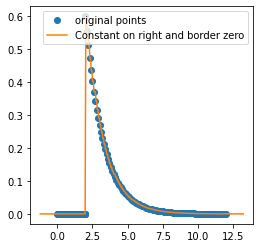

In [152]:
plot_timefunction(ekc3)

In [153]:
hawkestf3_1 = SimuHawkes(baseline=[λ01], kernels=[[ektf3]], end_time=end_time_1, verbose=False, seed=13)
hawkestf3_2 = SimuHawkes(baseline=[λ01], kernels=[[ektf3]], end_time=end_time_2, verbose=False, seed=13)
hawkestf3_3 = SimuHawkes(baseline=[λ01], kernels=[[ektf3]], end_time=end_time_3, verbose=False, seed=13)

In [154]:
multitf3_1 = SimuHawkesMulti(hawkestf3_1, n_simulations=n_paths)
multitf3_2 = SimuHawkesMulti(hawkestf3_2, n_simulations=n_paths)
multitf3_3 = SimuHawkesMulti(hawkestf3_3, n_simulations=n_paths)

In [155]:
multitf3_1.simulate()
multitf3_2.simulate()
multitf3_3.simulate()

In [167]:
%%time

np.mean(findθlat(multitf3_1.timestamps, lat=lat2), axis=0)

CPU times: user 21.2 s, sys: 40.7 ms, total: 21.2 s
Wall time: 21.6 s


array([1.4131202 , 0.59432248, 0.81423012])

In [168]:
%%time

np.mean(findθlat(multitf3_2.timestamps, lat=lat2), axis=0)

CPU times: user 3min 13s, sys: 258 ms, total: 3min 13s
Wall time: 3min 14s


array([1.26281987, 0.61530337, 0.80368133])

In [169]:
%%time

np.mean(findθlat(multitf3_3.timestamps, lat=lat2), axis=0)

CPU times: user 36min 38s, sys: 3.09 s, total: 36min 41s
Wall time: 36min 43s


array([1.20940096, 0.61256341, 0.78899146])

## Multidimensional Hawkes with latency

In [49]:
α11 = 0.6
β11 = 1.8
α12 = 0.4
β12 = 1.8
α21 = 0.6
β21 = 2.0
α22 = 0.4
β22 = 2.0
λ01 = 0.6
λ02 = 0.2

In [50]:
def ek11(t):
    return α11 * np.exp(-β11 * t)
def ek12(t):
    return α12 * np.exp(-β12 * t)
def ek21(t):
    return α21 * np.exp(-β21 * t)
def ek22(t):
    return α22 * np.exp(-β22 * t)

In [51]:
sup11 = 10
sup12 = 10
sup21 = 10
sup22 = 10

In [52]:
ekc11 = time_funclat(ek11, sup11, lat2)
ekc12 = time_funclat(ek12, sup12, lat2)
ekc21 = time_funclat(ek21, sup21, lat2)
ekc22 = time_funclat(ek22, sup22, lat2)

In [53]:
ektf11 = HawkesKernelTimeFunc(ekc11)
ektf12 = HawkesKernelTimeFunc(ekc12)
ektf21 = HawkesKernelTimeFunc(ekc21)
ektf22 = HawkesKernelTimeFunc(ekc22)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


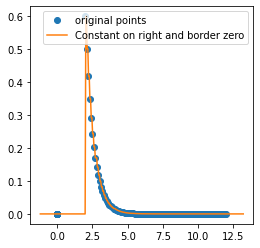

In [54]:
plot_timefunction(ekc11)

In [55]:
hawkestf2x2_1 = SimuHawkes(baseline=[λ01, λ02], kernels=[[ektf11, ektf12], [ektf21, ektf22]],
                          end_time=end_time_1, verbose=False, seed=13)
hawkestf2x2_2 = SimuHawkes(baseline=[λ01, λ02], kernels=[[ektf11, ektf12], [ektf21, ektf22]],
                          end_time=end_time_2, verbose=False, seed=13)
hawkestf2x2_3 = SimuHawkes(baseline=[λ01, λ02], kernels=[[ektf11, ektf12], [ektf21, ektf22]],
                          end_time=end_time_3, verbose=False, seed=13)

In [56]:
n_paths_2 = 1

In [57]:
multitf2x2_1 = SimuHawkesMulti(hawkestf2x2_1, n_simulations=n_paths_2)
multitf2x2_2 = SimuHawkesMulti(hawkestf2x2_2, n_simulations=n_paths_2)
multitf2x2_3 = SimuHawkesMulti(hawkestf2x2_3, n_simulations=n_paths_2)

In [58]:
multitf2x2_1.simulate()
multitf2x2_2.simulate()
multitf2x2_3.simulate()

In [67]:
def latwm(ts, m, lat):
    tsm = np.insert(ts[m], 0, 0, axis=0)
    return [[np.compress(np.logical_and(tsn < tsm[i] - lat, tsn >= tsm[i - 1] - lat), tsn)
                for i in range(1, len(tsm))] for tsn in ts]

In [70]:
# multitf2x2_1.timestamps[0]

In [71]:
[len(multitf2x2_1.timestamps[0][0]), len(multitf2x2_1.timestamps[0][1])]

[136, 74]

In [84]:
# latwm(multitf2x2_1.timestamps[0], 0, lat2)

In [85]:
# latwm(multitf2x2_1.timestamps[0], 1, lat2)

In [78]:
[[len(latwm(multitf2x2_1.timestamps[0], 0, lat2)[0]), len(latwm(multitf2x2_1.timestamps[0], 0, lat2)[1])],
 [len(latwm(multitf2x2_1.timestamps[0], 1, lat2)[0]), len(latwm(multitf2x2_1.timestamps[0], 1, lat2)[1])]]

[[136, 136], [74, 74]]

In [89]:
[[np.array([len(a) for a in latwm(multitf2x2_1.timestamps[0], 0, lat2)[0]]),
  np.array([len(a) for a in latwm(multitf2x2_1.timestamps[0], 0, lat2)[1]])],
 [np.array([len(a) for a in latwm(multitf2x2_1.timestamps[0], 1, lat2)[0]]),
  np.array([len(a) for a in latwm(multitf2x2_1.timestamps[0], 1, lat2)[1]])]]

[[array([0, 0, 0, 0, 4, 1, 0, 0, 2, 2, 0, 0, 3, 0, 0, 2, 0, 0, 0, 1, 0, 0,
         4, 3, 0, 0, 1, 0, 1, 4, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 5, 0, 0,
         2, 1, 0, 0, 7, 0, 0, 0, 1, 1, 1, 1, 4, 0, 0, 2, 1, 0, 0, 0, 0, 0,
         2, 3, 2, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 7, 0, 0, 1, 0, 1, 3, 0, 0,
         1, 0, 3, 1, 2, 1, 3, 0, 0, 0, 0, 2, 2, 0, 1, 0, 1, 1, 3, 2, 2, 0,
         0, 0, 0, 2, 4, 0, 1, 0, 1, 1, 1, 0, 1, 2, 0, 2, 2, 2, 0, 2, 0, 1,
         1, 1, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 1, 0, 0, 3, 1, 0, 2, 0, 2, 1, 0, 0, 0, 0, 0, 0,
         2, 1, 1, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
         0, 0, 0, 1, 4, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1,
         0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 4, 1, 0, 0,
         0, 0, 3, 2, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0,
         1, 0, 0, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 2, 0, 0, 0, 1,
         0, 1, 0, 0])],
 [array([4, 1, 0, 0, 2, 0, 0, 2, 0, 3, 2, 0, 1, 1, 2,

In [22]:
def lllatm(θ, ts, tsisn, M, m, lat=0):  # ts = {{}, ..., {}} length M; 1 <= m <= M
    λ0 = θ[0]  # scalar
    αm = θ[1]  # (M) array
    βm = θ[2]  # (M) array
    tsm = ts[m]
    tn = tsm[-1]
    nm = len(tsm)
    rin = np.zeros((M, nm + 1))
    for n in range(M):
        β = βm[n]
        tsis = tstsn[n]
        ebdts = np.exp(-β * np.diff(tsm))
        ri = np.zeros(nm + 1)
        for i in range(nm):
            tsi = tsis[i]
            if len(tsi) > 0:
                ri[i + 1] = ebdts[i] * ri[i] + np.sum(np.exp(-β * (tsm[i] - lat - tsi)))
            else:
                ri[i + 1] = ebdts[i] * ri[i]
        rin[n] = ri
    s1 = np.sum(1 - np.exp(-β * (tn - lat - ts[:-1]) * np.heaviside(tn - lat - ts[:-1], 0)))
    s2 = np.sum(np.log(λ0 + α * ri[1:]))
    return -(tn * (1 - λ0) - (α / β) * s1 + s2)

## Estimation of slowly decreasing Hawkes kernels: application to high-frequency order book dynamics

In [63]:
from tick.dataset import fetch_hawkes_bund_data

In [64]:
timestamps_list = fetch_hawkes_bund_data()

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/dataset/download_helper.py:216: UserWarning: TICK_DATASETS environment variable was not set. Saving dataset to the default location ~/tick_datasets
  .format(_TICK_HOME_ENV, _TICK_DEFAULT_HOME))


## Theoretical expected number of events for Poisson

In [ ]:


# def expnpoi(lambda0, time):
#     return lambda0 * time

## Theoretical expected number of events for Poisson with Exp Kernel

In [ ]:


# def expnpoiexpk(alpha, beta, time):
#     return (alpha / beta) * (1 - np.exp(- beta * time))

## Theoretical expected number of events for Hawkes with exponential kernel

In [ ]:


# def expnexp(lambda0, alpha, beta, time):
#     if alpha - beta == 0:
#         print('alpha=beta !')
#         return np.inf
#     else:
#         return lambda0 * time + lambda0 * alpha / ((alpha - beta)**2)\
#             * (np.exp((alpha - beta) * time) - 1 - (alpha - beta) * time)

## Defining Time Functions

In [4]:
support = 10
t0 = 5
# n_steps = int(support/t0)*1000

#### Using a function

In [5]:
def g1(t):
    return 0.3 * np.exp(-0.8 * t)

Introducing a latency with heaviside

In [ ]:
# def g2(t):
#     return 0.7 * 5.0 * np.exp(-5.0 * (t - t0))\
#         * np.heaviside(t - t0, 1) # To ensure zero before t0

In [6]:
def g3(t):
    return 0.1 * np.exp(-0.5 * t)

In [7]:
def g4(t):
    return 20 * np.exp(-100 * t)

### Creating a complete function with latency and linear interpolation

In [8]:
def time_func(f, support, t0=0, steps=100,
              inter_mode=TimeFunction.InterConstRight):
    t_values = np.linspace(0, support, steps + 1)
    y_values = f(t_values - t0) * np.heaviside(t_values - t0, 1)
    return TimeFunction(values=(t_values, y_values),
                        border_type=TimeFunction.Border0,
                        # inter_mode=TimeFunction.InterLinear,
                        inter_mode=inter_mode)

In [9]:
tf_1 = time_func(g1, support-t0, 0, 100)

In [10]:
tf_2 = time_func(g1, support, t0, 200)

In [11]:
tf_3 = time_func(g3, support-t0, 0, 100)

In [12]:
tf_4 = time_func(g4, 0.05, 0, 100)

In [ ]:
# print([[tf_1.value(0), tf_1.value(1)], [tf_2.value(t0), tf_2.value(1+t0)]])

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


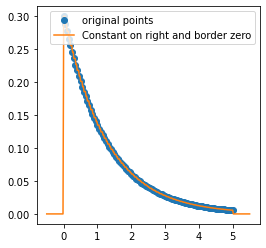

In [13]:
plot_timefunction(tf_1)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


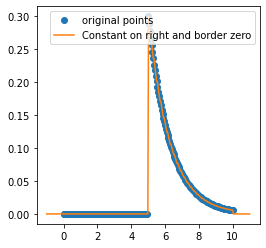

In [14]:
plot_timefunction(tf_2)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


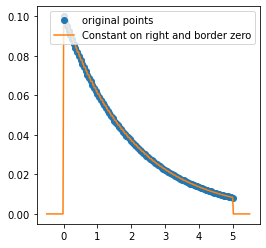

In [15]:
plot_timefunction(tf_3)

/Users/marcoscscarreira/Anaconda/anaconda3/envs/mcsc/lib/python3.7/site-packages/tick/plot/plot_timefunction.py:113: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


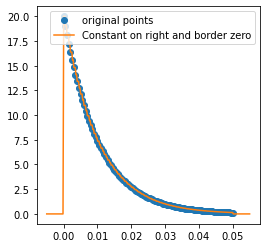

In [16]:
plot_timefunction(tf_4)

## Simulating Poisson Processes

In [ ]:
# run_time = 10
# intensity = 5

# poi = SimuPoissonProcess(intensity, end_time=run_time)
# poi.simulate()
# print([poi.n_total_jumps, expnpoi(intensity, run_time)])
# poi_timestamps = poi.timestamps

In [ ]:

# poiexp = SimuInhomogeneousPoisson([tf_1], end_time=20)
# poiexp.simulate()
# print([poiexp.n_total_jumps, expnpoiexpk(0.6, 0.8, 20)])
# poiexp_timestamps = poiexp.timestamps

## Defining Non-parametric Kernels

In [17]:
kernel_1 = HawkesKernelTimeFunc(tf_1)
print(kernel_1.get_norm())

0.3756276470101976


In [18]:
kernel_2 = HawkesKernelTimeFunc(tf_2)
print(kernel_2.get_norm())

0.37539934443323647


In [19]:
kernel_3 = HawkesKernelTimeFunc(tf_3)
print(kernel_3.get_norm())

0.18591591587842743


In [20]:
kernel_4 = HawkesKernelTimeFunc(tf_4)
print(kernel_4.get_norm())

0.20371638532624292


## Defining Parametric Kernels

In [ ]:
# kernel_sumexp = HawkesKernelSumExp(
#     intensities=np.array([0.1, 0.2, 0.1]),
#     decays=np.array([1.0, 3.0, 7.0]))

## Simulations

### SimuHawkes

In [ ]:
# hawkes = SimuHawkes(n_nodes=1, end_time=40, seed=1398)
# hawkes.set_kernel(0, 0, kernel_sumexp)
# hawkes.set_baseline(0, 1.)

In [ ]:
# dt = 0.01
# hawkes.track_intensity(dt)
# hawkes.simulate()

In [ ]:
# timestamps = hawkes.timestamps
# intensity = hawkes.tracked_intensity
# intensity_times = hawkes.intensity_tracked_times
# mean_intensity = hawkes.mean_intensity()

In [ ]:
# pd.Series(np.arange(1, len(timestamps[0])+1),
#           index=timestamps[0]).plot(drawstyle='steps-post')

In [ ]:
# plot_point_process(hawkes)

### SimuHawkesMulti

In [21]:
hawkes_m1 = SimuHawkes(n_nodes=1, end_time=20000)
hawkes_m1.set_baseline(0, 1.2)
hawkes_m1.set_kernel(0, 0, kernel_1)

hawkes_m2 = SimuHawkes(n_nodes=1, end_time=20000)
hawkes_m2.set_baseline(0, 1.2)
hawkes_m2.set_kernel(0, 0, kernel_2)

hawkes_m3 = SimuHawkes(n_nodes=1, end_time=20000)
hawkes_m3.set_baseline(0, 1.2)
hawkes_m3.set_kernel(0, 0, kernel_3)

hawkes_m4 = SimuHawkes(n_nodes=1, end_time=20000)
hawkes_m4.set_baseline(0, 1.2)
hawkes_m4.set_kernel(0, 0, kernel_4)

In [22]:
hawkes_mv1 = SimuHawkes(n_nodes=2, end_time=20)
hawkes_mv1.set_baseline(0, 0.1)
hawkes_mv1.set_baseline(1, 0.2)
hawkes_mv1.set_kernel(0, 0, kernel_1)
hawkes_mv1.set_kernel(0, 1, kernel_2)
hawkes_mv1.set_kernel(1, 0, kernel_2)
hawkes_mv1.set_kernel(1, 1, kernel_3)

In [23]:
multi_1 = SimuHawkesMulti(hawkes_m1, n_simulations=1)
multi_1.simulate()

multi_2 = SimuHawkesMulti(hawkes_m2, n_simulations=1)
multi_2.simulate()

multi_3 = SimuHawkesMulti(hawkes_m3, n_simulations=1)
multi_3.simulate()

multi_4 = SimuHawkesMulti(hawkes_m4, n_simulations=1)
multi_4.simulate()

---------------------------------------------
Launching simulation using SimuHawkesMulti...
----------------------------------------
Launching simulation using SimuHawkes...
Done simulating using SimuHawkes in 3.52e-02 seconds.
Done simulating using SimuHawkesMulti in 3.38e-01 seconds.
---------------------------------------------
Launching simulation using SimuHawkesMulti...
----------------------------------------
Launching simulation using SimuHawkes...
Done simulating using SimuHawkes in 1.03e-01 seconds.
Done simulating using SimuHawkesMulti in 3.16e-01 seconds.
---------------------------------------------
Launching simulation using SimuHawkesMulti...
----------------------------------------
Launching simulation using SimuHawkes...
Done simulating using SimuHawkes in 2.29e-02 seconds.
Done simulating using SimuHawkesMulti in 2.15e-01 seconds.
---------------------------------------------
Launching simulation using SimuHawkesMulti...
----------------------------------------
Launch

In [24]:
multi_v1 = SimuHawkesMulti(hawkes_mv1, n_simulations=1)
multi_v1.simulate()

---------------------------------------------
Launching simulation using SimuHawkesMulti...
----------------------------------------
Launching simulation using SimuHawkes...
Done simulating using SimuHawkes in 8.38e-03 seconds.
Done simulating using SimuHawkesMulti in 1.12e-01 seconds.


In [25]:
multi_1_timestamps = multi_1.timestamps
multi_1_mean_intensity = np.mean(np.array(multi_1.mean_intensity))
n_points_1 = np.array([len(t[0]) for t in multi_1_timestamps])

multi_2_timestamps = multi_2.timestamps
multi_2_mean_intensity = np.mean(np.array(multi_2.mean_intensity))
n_points_2 = np.array([len(t[0]) for t in multi_2_timestamps])

multi_3_timestamps = multi_3.timestamps
multi_3_mean_intensity = np.mean(np.array(multi_3.mean_intensity))
n_points_3 = np.array([len(t[0]) for t in multi_3_timestamps])

multi_4_timestamps = multi_4.timestamps
multi_4_mean_intensity = np.mean(np.array(multi_4.mean_intensity))
n_points_4 = np.array([len(t[0]) for t in multi_4_timestamps])

print([np.mean(n_points_1), np.mean(n_points_2), np.mean(n_points_3)])

# print([np.mean(first_point_1), np.mean(first_point_2)])

[37929.0, 38651.0, 29496.0]


In [26]:
multi_v1_timestamps = multi_v1.timestamps
multi_v1_mean_intensity = np.mean(np.array(multi_v1.mean_intensity))
n_points_v1 = np.array([len(t) for t in multi_v1_timestamps[0]])

## Learning

#### Non-parametric

##### HawkesEM

In [31]:
t0

5

In [27]:

kern_d =\
    np.concatenate(
        (np.array([0., 0.2*t0,  0.5*t0, 0.75*t0, 0.9*t0, t0, 1.25*t0, 1.5*t0]),
         np.array([0.02, 0.05, 0.075, 0.1, 0.2, 0.5, 0.75, 1., 2.,
                   support])))

In [28]:

em_1 = HawkesEM(kernel_discretization=kern_d, max_iter=10000, tol=1e-5,
                verbose=True, n_threads=-1)
em_1.fit(multi_1_timestamps)
em_1_baseline = em_1.baseline
em_1_kernel = em_1.kernel
em_1_score = em_1.score()

Launching the solver HawkesEM...
  n_iter  | rel_baseline | rel_kernel
        0 |     1.04e-01 |        nan
       10 |     2.04e-03 |        nan
       20 |     2.55e-03 |        nan
       30 |     8.10e-04 |        nan
       40 |     2.36e-05 |        nan
       50 |     4.54e-04 |        nan
       60 |     6.06e-04 |        nan
       70 |     6.26e-04 |        nan
       80 |     6.00e-04 |        nan
       90 |     5.56e-04 |        nan
      100 |     5.04e-04 |        nan
      110 |     4.51e-04 |        nan
      120 |     4.01e-04 |        nan
      130 |     3.54e-04 |        nan
      140 |     3.14e-04 |        nan
      150 |     2.78e-04 |        nan
      160 |     2.47e-04 |        nan
      170 |     2.20e-04 |        nan
      180 |     1.97e-04 |        nan
      190 |     1.77e-04 |        nan
      200 |     1.59e-04 |        nan
      210 |     1.44e-04 |        nan
      220 |     1.31e-04 |        nan
      230 |     1.19e-04 |        nan
      240 |     1

In [29]:

em_2 = HawkesEM(kernel_discretization=kern_d, max_iter=10000, tol=1e-5,
                verbose=True, n_threads=-1)
em_2.fit(multi_2_timestamps)
em_2_baseline = em_2.baseline
em_2_kernel = em_2.kernel
em_2_score = em_2.score()

Launching the solver HawkesEM...
  n_iter  | rel_baseline | rel_kernel
        0 |     6.13e-02 |        nan
       10 |     8.25e-04 |        nan
       20 |     3.81e-04 |        nan
       30 |     3.21e-04 |        nan
       40 |     6.34e-04 |        nan
       50 |     6.87e-04 |        nan
       60 |     6.48e-04 |        nan
       70 |     5.94e-04 |        nan
       80 |     5.48e-04 |        nan
       90 |     5.13e-04 |        nan
      100 |     4.83e-04 |        nan
      110 |     4.56e-04 |        nan
      120 |     4.28e-04 |        nan
      130 |     4.00e-04 |        nan
      140 |     3.72e-04 |        nan
      150 |     3.44e-04 |        nan
      160 |     3.17e-04 |        nan
      170 |     2.91e-04 |        nan
      180 |     2.67e-04 |        nan
      190 |     2.44e-04 |        nan
      200 |     2.23e-04 |        nan
      210 |     2.04e-04 |        nan
      220 |     1.87e-04 |        nan
      230 |     1.71e-04 |        nan
      240 |     1

In [30]:

print(pd.DataFrame(
    {'0': em_1_kernel[0, 0],
     't0': em_2_kernel[0, 0]}).head(10))

          0        t0
0  0.126268  0.018076
1  0.352413  0.067005
2  0.310970  0.035876
3  0.327464  0.037983
4  0.278875  0.000080
5  0.244932  0.001115
6  0.175483  0.001621
7  0.167957  0.002626
8       NaN       NaN
9  0.091255  0.000233


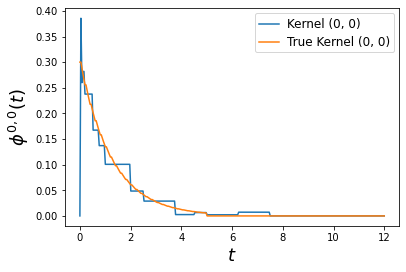

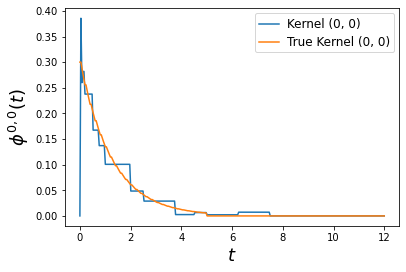

In [35]:
plot_hawkes_kernels(em_1, hawkes=hawkes_m1)

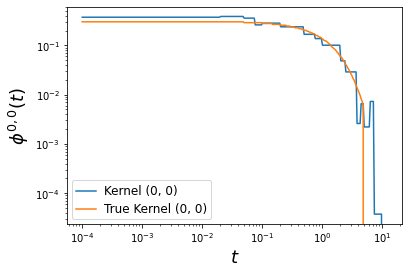

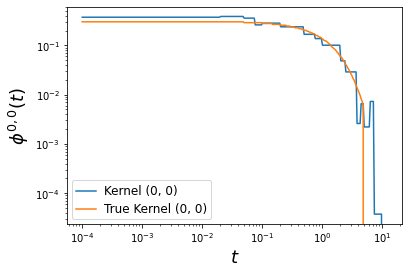

In [36]:
plot_hawkes_kernels(em_1, hawkes=hawkes_m1, log_scale=True)

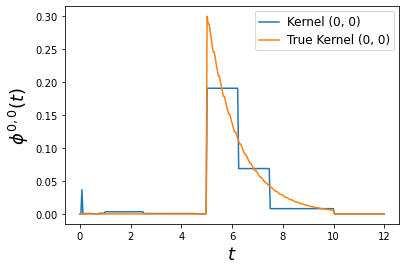

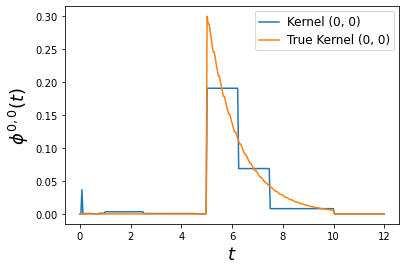

In [37]:
plot_hawkes_kernels(em_2, hawkes=hawkes_m2)

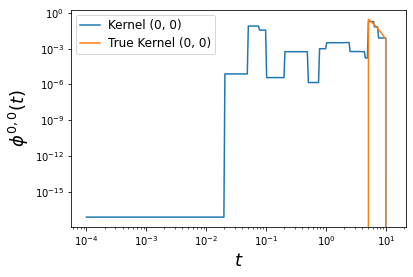

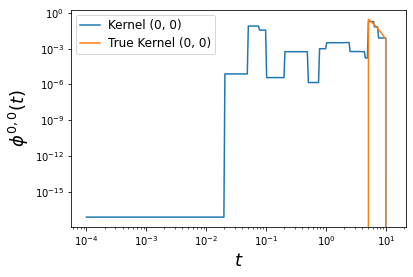

In [38]:
plot_hawkes_kernels(em_2, hawkes=hawkes_m2, log_scale=True)

##### HawkesBasisKernels

In [ ]:

# bk_1 = HawkesBasisKernels(kernel_support=4, n_basis=1, kernel_size=100,
#                           max_iter=10000, tol=1e-5, C=0.1, verbose=True,
#                           n_threads=-1)
# bk_1.fit(multi_1_timestamps)
# bk_1_baseline = bk_1.baseline
# bk_1_amplitudes = bk_1.amplitudes
# bk_1_kernel = bk_1.basis_kernels

# bk_2 = HawkesBasisKernels(kernel_support=4, n_basis=1, kernel_size=100,
#                           max_iter=10000, tol=1e-5, C=0.1, verbose=True,
#                           n_threads=-1)
# bk_2.fit(multi_2_timestamps)
# bk_2_baseline = bk_2.baseline
# bk_2_amplitudes = bk_2.amplitudes
# bk_2_kernel = bk_2.basis_kernels

In [ ]:
# plot_hawkes_kernels(bk_1, hawkes=hawkes_m1)

In [ ]:
# plot_hawkes_kernels(bk_2, hawkes=hawkes_m2)

In [ ]:
# plot_basis_kernels(bk, basis_kernels=[g1, g2])

#### Parametric

##### HawkesSumExpKern

In [ ]:

# sek_1 = HawkesSumExpKern(decays=[5.],
#                          n_baselines=1, penalty='l2', solver='agd',
#                          elastic_net_ratio=0.8,
#                          max_iter=10000, tol=1e-5, C=1000., verbose=True)
# sek_1.fit(multi_1_timestamps)
# sek_1_baseline = sek_1.baseline
# sek_1_adjacency = sek_1.adjacency
# sek_1_score = sek_1.score()

In [ ]:

# sek_2 = HawkesSumExpKern(decays=[5.],
#                          n_baselines=1, penalty='l2', solver='agd',
#                          elastic_net_ratio=0.8,
#                          max_iter=10000, tol=1e-5, C=1000., verbose=True)
# sek_2.fit(multi_2_timestamps)
# sek_2_baseline = sek_2.baseline
# sek_2_adjacency = sek_2.adjacency
# sek_2_score = sek_2.score()

In [ ]:
# plot_hawkes_kernels(sek_1, hawkes=hawkes_m1)

In [ ]:
# plot_hawkes_kernels(sek_1, hawkes=hawkes_m1, log_scale=True)

In [ ]:
# plot_hawkes_kernels(sek_2, hawkes=hawkes_m2)

In [ ]:
# plot_hawkes_kernels(sek_2, hawkes=hawkes_m2, log_scale=True)

##### HawkesSumGaussians

In [ ]:
# sg_1 = HawkesSumGaussians(max_mean_gaussian=4, n_gaussians=7,
#                         lasso_grouplasso_ratio=0.5,
#                         max_iter=10000, tol=1e-5, C=1000., verbose=True)
# sg_1.fit(multi_1_timestamps)
# sg_1_baseline = sg_1.baseline
# sg_1_amplitudes = sg_1.amplitudes
# sg_1_means = sg_1.means_gaussians
# sg_1_std = sg_1.std_gaussian

# sg_2 = HawkesSumGaussians(max_mean_gaussian=4, n_gaussians=7,
#                         lasso_grouplasso_ratio=0.5,
#                         max_iter=10000, tol=1e-5, C=1000., verbose=True)
# sg_2.fit(multi_2_timestamps)
# sg_2_baseline = sg_2.baseline
# sg_2_amplitudes = sg_2.amplitudes
# sg_2_means = sg_2.means_gaussians
# sg_2_std = sg_2.std_gaussian

In [ ]:
# plot_hawkes_kernels(sg, hawkes=hawkes_m)

In [39]:

def arec(lvav, lambda0, alpha, beta, dti):
    newav = np.exp(- beta * dti) * (1 + lvav[1])
    return [lvav[0] + np.log(lambda0 + alpha * newav), newav]

def loglk1(lambda0, alpha, beta, tmstmp):
    tdiff = np.diff(tmstmp)
    ans = [np.log(lambda0), 0]
    for t in tdiff:
        ans = arec(ans, lambda0, alpha, beta, t)
    return ans[0]

def loglk2(lambda0, alpha, beta, tmstmp):
    tt = tmstmp[-1]
    lt = lambda0 * tt
    return lt - (alpha / beta) * np.sum(np.exp(- beta * (tt - tmstmp[:-1]))-1)

def loglk(lambda0, alpha, beta, tmstmp):
    return loglk1(lambda0, alpha, beta, tmstmp) -\
        loglk2(lambda0, alpha, beta, tmstmp)

def loglkopt(theta, tmstmp):
    lambda0 = theta[0]
    alpha = theta[1]
    beta = theta[2]
    return -(loglk1(lambda0, alpha, beta, tmstmp) -
        loglk2(lambda0, alpha, beta, tmstmp))

In [40]:

def fkern(lambda0, alpha, beta, ti, tmstmp, latency=0.):
    dtk = ti - latency - np.compress(tmstmp < ti - latency, tmstmp)
    return np.log(lambda0 + alpha * np.sum(np.exp(- beta * dtk)))


def loglk1lat(lambda0, alpha, beta, tmstmp, latency=0.):
    return np.sum(np.array([fkern(lambda0, alpha, beta, ti, tmstmp, latency)
                for ti in tmstmp]))

def loglk2lat(lambda0, alpha, beta, tmstmp, latency=0.):
    tt = tmstmp[-1]
    lt = lambda0 * tt
    abt = np.sum(np.exp(- beta * np.maximum(0., tt - latency - tmstmp[:-1]))-1)
    return lt - (alpha / beta) * abt

def loglklatopt(theta, tmstmp, latency=0.):
    lambda0 = theta[0]
    alpha = theta[1]
    beta = theta[2]
    return -(loglk1lat(lambda0, alpha, beta, tmstmp, latency) -
        loglk2lat(lambda0, alpha, beta, tmstmp, latency))

In [41]:

def fkerncut(lambda0, alpha, beta, ti, tmstmp, cutoff, latency=0.):
    tmstamplat = np.compress(tmstmp < ti - latency, tmstmp)
    dtk = ti - latency - np.where(tmstamplat >= ti - latency - cutoff,
                                  tmstamplat, -np.inf)
    return np.log(lambda0 + alpha * np.sum(np.exp(- beta * dtk)))


def loglk1latcut(lambda0, alpha, beta, tmstmp, cutoff, latency=0.):
    return np.sum(np.array([fkerncut(
        lambda0, alpha, beta, ti, tmstmp, cutoff, latency) for ti in tmstmp]))

def loglk2latcut(lambda0, alpha, beta, tmstmp, cutoff, latency=0.):
    tt = tmstmp[-1]
    lt = lambda0 * tt
    tmstamplat = np.compress(tmstmp[:-1] < tt - latency, tmstmp[:-1])
    abt = np.sum(np.exp(
        - beta * np.maximum(0., tt - latency -
                            np.where(tmstamplat >= tt - latency - cutoff,
                                     tmstamplat, -np.inf)))-1)
    return lt - (alpha / beta) * abt

def loglklatoptcut(theta, tmstmp, cutoff, latency=0.):
    lambda0 = theta[0]
    alpha = theta[1]
    beta = theta[2]
    return -(loglk1latcut(lambda0, alpha, beta, tmstmp, cutoff, latency) -
             loglk2latcut(lambda0, alpha, beta, tmstmp, cutoff, latency))

In [42]:

def fmkern(lambda0, alpha, beta, m, ti, tmstmp, latency=0.):
    dtk = ti - latency - np.compress(tmstmp < ti - latency, tmstmp)
    return np.log(lambda0 + alpha * np.sum(np.exp(- beta * dtk)))


def loglk1latm(lambda0, alpha, beta, m, tmstmp, latency=0.):
    return np.sum(np.array([fmkern(lambda0, alpha, beta, ti, tmstmp, latency)
                for ti in tmstmp]))

def loglk2latm(lambda0, alpha, beta, m, tmstmp, latency=0.):
    tt = tmstmp[-1]
    lt = lambda0 * tt
    abt = np.sum(np.exp(- beta * np.maximum(0., tt - latency - tmstmp[:-1]))-1)
    return lt - (alpha / beta) * abt

def loglklatoptm(theta, tmstmp, latency=0.):
    lambda0 = theta[0]
    alpha = theta[1]
    beta = theta[2]
    return -(loglk1lat(lambda0, alpha, beta, tmstmp, latency) -
        loglk2lat(lambda0, alpha, beta, tmstmp, latency))

In [44]:

lat = 1
tmst = multi_v1_timestamps[0].copy()

dtkmij = [
    [
      [tm[i] - lat - np.compress(tj < tm[i] - lat, tj) for tj in tmst]
      for i in np.arange(len(tm))]
    for tm in tmst]

dtkmji = [
    [
     [tm[i] - lat - np.compress(tj < tm[i] - lat, tj)
      for i in np.arange(len(tm))]
     for tj in tmst]
    for tm in tmst]


lastt = np.array([tm[-1] for tm in tmst])

# def llm(theta, n, dtk, ltm):
#     nrg = np.arange(n)
#     lambda0 = theta[:n].copy()
#     alpha = theta[n:n*n+n].copy().reshape((n, n))
#     beta = theta[n*n+n:].copy().reshape((n, n))
#     for m in nrg:
#         for i in 

In [ ]:

# def areclat(lvav, lambda0, alpha, beta, t1, t2, tmstmp, latency=0.):
#     prevt1 = np.compress(tmstmp < t1, tmstmp)
#     tw1 = np.compress(prevt1 >= t1 - latency, prevt1)
#     prevt2 = np.compress(tmstmp < t2, tmstmp)
#     tw2 = np.compress(prevt2 >= t2 - latency, prevt2)
#     dti = t1 - t2
#     nsum1 = np.sum(np.exp(- beta * (t1 - tw1)))
#     nsum2 = np.sum(np.exp(- beta * (t2 - tw2)))
#     newav = np.exp(- beta * dti) * (np.exp(beta * latency) + lvav[1]) -\
#         np.exp(beta * latency) * (lsum1 - np.exp(- beta * dti) * lsum2)
#     return [lvav[0] + np.log(lambda0 + alpha * newav), newav]

In [ ]:

# teste0 = np.array([0.599672, 0.619958, 0.787331, 1.01128, 1.04814, 1.08816,\
#                    1.09742, 2.1432, 2.46201, 2.88413, 2.95975, 3.57213,\
#                    4.94965, 5.2049, 6.95427, 7.13965, 8.33601, 8.55164, 8.781,\
#                    8.92576, 9.41525, 10.1974, 10.2142, 10.5937, 10.6832,\
#                    11.1033, 11.2313, 11.5169, 11.5633, 11.805, 12.1914,\
#                    12.3337, 12.4833, 12.5905, 12.6663, 14.1659, 14.1986,\
#                    14.3381, 14.4392, 14.6677, 15.4212, 15.5708, 15.6997,\
#                    16.2507, 16.3233, 17.6775, 17.857, 19.1116])

# tt0 = teste0[-1]

# loglk2(1.2, 0.6, 0.8, teste0)

In [ ]:

# hawkes_m1 = SimuHawkes(n_nodes=1, end_time=2000)
# hawkes_m1.set_baseline(0, 1.2)
# hawkes_m1.set_kernel(0, 0, HawkesKernelExp(0.6 / 0.8, 0.8))
# hawkes_m1.simulate()

In [ ]:

# hawkes_m1_n_jumps = hawkes_m1.n_total_jumps
# hawkes_m1_timestamps = hawkes_m1.timestamps[0]

In [ ]:

# print(loglk(1.2, 0.6, 0.8, hawkes_m1_timestamps))

In [ ]:

# print(loglklat(1.2, 0.6, 0.8, hawkes_m1_timestamps, 1))

In [ ]:

# def loglkf(x):
#     return -loglk(x[0], x[1], x[2], hawkes_m1_timestamps)

In [45]:

start = timeit.default_timer()
optim0 = partial(loglkopt, tmstmp=multi_4_timestamps[0][0])
print(optim0([1.2, 20., 100.]))
bounds = [(0.01, 2.0), (0.01, 100.), (0.01, 200.)]
# x0 = np.array([1., 0.3, 0.5])
# res = minimize(loglkf, x0, method='SLSQP', bounds=bounds)
res0 = optimize.shgo(optim0, bounds)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')
print(res0)

8816.039531039525
Time Spent:  17  seconds
     fun: 8813.516626619989
    funl: array([8813.51662662])
 message: 'Optimization terminated successfully.'
    nfev: 184
     nit: 2
   nlfev: 175
   nlhev: 0
   nljev: 25
 success: True
       x: array([  1.21417249,  20.45196681, 100.6466732 ])
      xl: array([[  1.21417249,  20.45196681, 100.6466732 ]])


In [46]:

start = timeit.default_timer()
optim1 = partial(loglklatopt, tmstmp=multi_4_timestamps[0][0])
print(optim1([1.2, 20., 100.]))
bounds = [(0.01, 2.0), (0.01, 100.), (0.01, 200.)]
# x0 = np.array([1., 0.3, 0.5])
# res = minimize(loglkf, x0, method='SLSQP', bounds=bounds)
res1 = optimize.shgo(optim1, bounds)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')
print(res1)

8816.039531039492
Time Spent:  300  seconds
     fun: 8813.5166261519
    funl: array([8813.51662615])
 message: 'Optimization terminated successfully.'
    nfev: 67
     nit: 2
   nlfev: 58
   nlhev: 0
   nljev: 11
 success: True
       x: array([  1.21417119,  20.45223883, 100.64814377])
      xl: array([[  1.21417119,  20.45223883, 100.64814377]])


In [47]:

start = timeit.default_timer()
optim1b = partial(loglklatoptcut, tmstmp=multi_4_timestamps[0][0],
                  cutoff=1e-1)
print(optim1b([1.2, 20., 100.]))
bounds = [(0.01, 2.0), (0.01, 100.), (0.01, 200.)]
# x0 = np.array([1., 0.3, 0.5])
# res = minimize(loglkf, x0, method='SLSQP', bounds=bounds)
res1b = optimize.shgo(optim1b, bounds)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')
print(res1b)

8816.294652585013
Time Spent:  604  seconds
     fun: 8813.755577566455
    funl: array([8813.75557757])
 message: 'Optimization terminated successfully.'
    nfev: 127
     nit: 2
   nlfev: 118
   nlhev: 0
   nljev: 22
 success: True
       x: array([  1.21423075,  20.46629008, 100.73665518])
      xl: array([[  1.21423075,  20.46629008, 100.73665518]])


In [48]:

start = timeit.default_timer()
optim2 = partial(loglklatopt, tmstmp=multi_2_timestamps[0][0])
print(optim2([1.2, 0.6, 0.8]))
bounds = [(0.5, 2.0), (0.1, 1.5), (0.2, 1.6)]
# x0 = np.array([1., 0.3, 0.5])
# res = minimize(loglkf, x0, method='SLSQP', bounds=bounds)
res2 = optimize.shgo(optim2, bounds)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')
print(res2)

16557.14839153376
Time Spent:  245  seconds
     fun: 13425.639698864328
    funl: array([13425.63969886])
 message: 'Optimization terminated successfully.'
    nfev: 34
     nit: 2
   nlfev: 25
   nlhev: 0
   nljev: 6
 success: True
       x: array([1.79454792, 0.1       , 1.6       ])
      xl: array([[1.79454792, 0.1       , 1.6       ]])


In [49]:

start = timeit.default_timer()
optim3 = partial(loglklatopt, tmstmp=multi_2_timestamps[0][0], latency=5)
print(optim3([1.2, 0.6, 0.8]))
bounds = [(0.01, 2.0), (0.01, 1.5), (0.01, 1.6)]
# x0 = np.array([1., 0.3, 0.5])
# res = minimize(loglkf, x0, method='SLSQP', bounds=bounds)
res3 = optimize.shgo(optim3, bounds)
stop = timeit.default_timer()
print('Time Spent: ', round(stop - start), ' seconds')
print(res3)

15160.668547910944
Time Spent:  851  seconds
     fun: 12851.820844344318
    funl: array([12851.82084434])
 message: 'Optimization terminated successfully.'
    nfev: 121
     nit: 2
   nlfev: 112
   nlhev: 0
   nljev: 22
 success: True
       x: array([1.21955473, 0.31099378, 0.85742666])
      xl: array([[1.21955473, 0.31099378, 0.85742666]])
